In [8]:
# %pip install -U huggingface_hub
# %pip install -U datasets
# %hf auth login

In [25]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
path_to_data = Path("data/trace_dataset.csv")

if not path_to_data.exists() or path_to_data.stat().st_size == 0:
    df = pd.read_parquet("hf://datasets/PatronusAI/trace-dataset/data/train-00000-of-00001.parquet")
    df.to_csv("data/trace_dataset.csv", index=False)
else :
    df = pd.read_csv(path_to_data)

In [19]:
#some stats

print("Dataset head:")
display(df.head())

print("Dataset description:")
display(df.describe())

print("Dataset info:")
display(df.info())

print("Shape of the dataset:", df.shape)

Dataset head:


,trajectory_id,conversation,label
0,trajectory_0389,"[{""role"": ""user"", ""content"": ""Our WebSocket se...",0
1,trajectory_0223,"[{""role"": ""user"", ""content"": ""Refactor our ETL...",0
2,trajectory_0366,"[{""role"": ""user"", ""content"": ""Our live encoder...",0
3,trajectory_0448,"[{""role"": ""user"", ""content"": ""Hey, our CI pipe...",0
4,trajectory_0018,"[{""role"": ""user"", ""content"": ""We have a SOC2 a...",1.2.3


Dataset description:


,trajectory_id,conversation,label
count,517,517,517
unique,517,516,43
top,trajectory_0389,"[{""role"": ""user"", ""content"": ""I need help impl...",0
freq,1,2,249


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   trajectory_id  517 non-null    str  
 1   conversation   517 non-null    str  
 2   label          517 non-null    str  
dtypes: str(3)
memory usage: 21.7 MB


None

Shape of the dataset: (517, 3)


Unique labels:
label
0                             249
1.1.1                          37
1.1.2                          36
1.2.3                          25
1.1.3                          21
1.2.2                          16
1.4.2                          16
1.3.1                          15
1.3.2                          14
1.4.1                          14
1.1.2, 1.2.1                   10
1.2.1                           6
1.1.1, 1.1.2                    5
1.1.2, 1.3.1                    4
1.1.3, 1.2.1                    4
1.1.2, 1.1.3                    4
1.1.3, 1.4.2                    4
1.2.1, 1.2.3                    3
1.1.1, 1.1.3                    3
1.1.3, 1.2.3                    3
1.1.1, 1.1.3, 1.2.1             3
1.1.2, 1.1.3, 1.3.1             2
1.1.1, 1.4.2                    2
1.1.1, 1.1.2, 1.1.3             2
1.2.2, 1.4.1, 1.4.2             1
1.1.1, 1.3.2                    1
1.1.1, 1.1.2, 1.4.1             1
1.2.1, 1.2.2, 1.3.1, 1.4.1      1
1.1.2, 1.4.1               

<StringDtype(na_value=nan)>

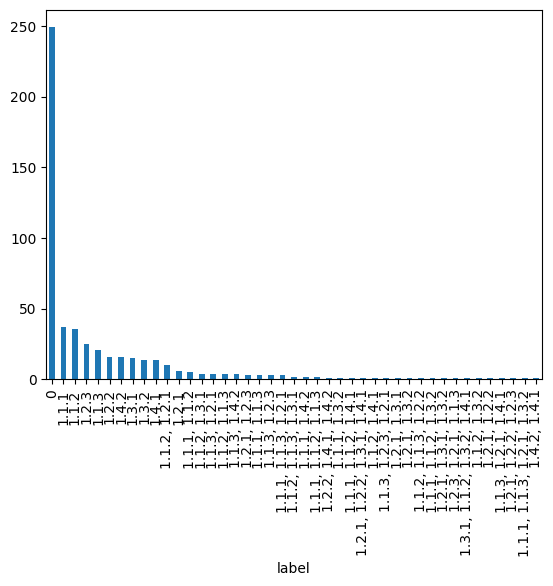

In [34]:
#unique labels

print("Unique labels:")
print(df["label"].value_counts())
df["label"].value_counts().plot(kind="bar")
df["label"].dtype

In [35]:
# for base analysis, map: everything which is not '1' --> '0'

df["binary_label"] = df["label"].apply(lambda x: 0 if x == '0' else 1)
df["length"] = df["conversation"].fillna("").astype(str).str.len()

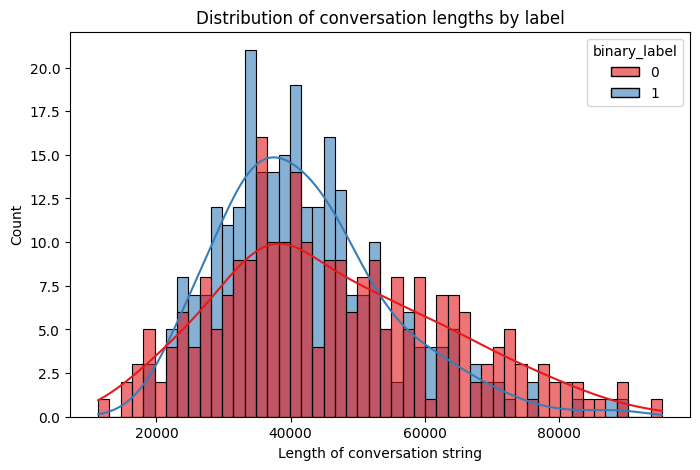

In [37]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="length", hue="binary_label", bins=50, kde=True, palette="Set1", alpha=0.6)
plt.xlabel("Length of conversation string")
plt.ylabel("Count")
plt.title("Distribution of conversation lengths by label")
plt.show()

In [38]:
#feel free to contibue